In [1]:
# kaggle API를 사용하기 위해 API 키 json 파일 업로드
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"jhw0714","key":"5ebfcd63c0dd4e608eb3f7b6fbbb5ebd"}'}

In [2]:
# kaggle.json 파일을 적절한 디렉토리로 옮긴다.
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# 데이터셋을 다운로드한다.
!kaggle datasets download -d vladimirvorobevv/chatgpt-paraphrases
!unzip -o /content/chatgpt-paraphrases.zip -d /content/sample_data

 98% 59.0M/60.0M [00:03<00:00, 28.2MB/s]
100% 60.0M/60.0M [00:03<00:00, 20.1MB/s]
Archive:  /content/chatgpt-paraphrases.zip
  inflating: /content/sample_data/chatgpt_paraphrases.csv  


In [3]:
# 파이스파크 설치
!pip install pyspark
!pip install -U -q PyDrive
!apt install openjdk-8-jdk-headless -qq

# 한국어 텍스트 전처리를 도와주는 NLTK 패키지
!pip install nltk

import os
import re
from google.colab import drive
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-8-openjdk-amd64"
drive.mount('/content/drive')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 316.9/316.9 MB 3.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pyspark: filename=pyspark-3.5.0-py2.py3-none-any.whl size=317425344 sha256=352f88e34574d77ee4a91f71e03fb2824b3b09a9a2fdff40b4b315566dd5b126
  Stored in directory: /root/.cache/pip/wheels/41/4e/10/c2cf2467f71c678cfc8a6b9ac9241e5e44a01940da8fbb17fc
Successfully built pyspark
The following additional packages will be installed:
  libxtst6 openjdk-8-jre-headless
Suggested packages:
  openjdk-8-demo openjdk-8-source libnss-mdns fonts-dejavu-extra fonts-nanum fonts-ipafont-gothic
  fonts-ipafont-mincho fonts-wqy-microhei fonts-wqy-zenhei fonts-indic
The following NEW packages will be installed:
  libxtst6 openjdk-8-jdk-headless openjdk-8-jre-headless
0 upgraded, 3 newly installed, 0 to remove and 10 not upgraded.
Need to get 39.7 MB of archives.
After this operation, 144 MB of additional disk space will be used.
Selecting previously unselected package

In [4]:
# Let's import the libraries we will need
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

import pyspark
from pyspark.sql import *
from pyspark.sql.functions import *
# SparkContext is the entry point to any spark functionality.
# SparkConf provides configurations to run a Spark application.
from pyspark import SparkContext, SparkConf

# create the Spark Session
spark = SparkSession.builder.appName("WordCount").getOrCreate()

# create the Spark Context
sc = spark.sparkContext

In [5]:
data=pd.read_csv('/content/sample_data/chatgpt_paraphrases.csv')

In [6]:
# 각 문장을 사람이 작성했는지, AI가 작성했는지 태그
category={}
for i in range(len(data)):
    chatgpt=data.iloc[i]["paraphrases"][1:-1].split(', ')
    for j in chatgpt[:1]:
        category[j[1:-1]]='chatgpt'
    category[data.iloc[i]['text']]="human"

In [7]:
# 사람의 작성한 문장과 AI가 작성한 문장을 분리
total_paraphrases=pd.DataFrame(category.items(),columns=["text","category"])
human_paraphrases = total_paraphrases[total_paraphrases['category'] == 'human']
gpt_paraphrases = total_paraphrases[total_paraphrases['category'] == 'chatgpt']

In [8]:
import nltk

from nltk.stem import PorterStemmer
from nltk.stem import LancasterStemmer
from nltk.stem import RegexpStemmer
from nltk.stem import WordNetLemmatizer

from nltk.tokenize import sent_tokenize
from nltk.tokenize import word_tokenize

from nltk.corpus import stopwords

nltk.download('punkt')
nltk.download('wordnet')
nltk.download('stopwords')

lemmatizer = WordNetLemmatizer()

use_stopwords = True
english_stop_list = [".", ",", "!", "?", ")", "(", "'", '"', "]", "[", "{", "}", ":", ";", "<", ">", "~", "''", "``"]

if use_stopwords:
  english_stop_list += list(stopwords.words('english'))

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.utils import resample
from sklearn.decomposition import TruncatedSVD
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt
%matplotlib inline

use_stopwords = False
use_random_sample = False
target_paraphrases = gpt_paraphrases

if (use_random_sample):
  datas = resample(target_paraphrases, n_samples=20000, random_state = 666)
else:
  datas = target_paraphrases

if (use_stopwords):
  example = datas['text']
  filtered_data = []
  for i,sentense in enumerate(datas['text']):
    word_tokens = word_tokenize(sentense)
    filtered_data.append([])
    for word in word_tokens:
        if word not in english_stop_list:
            filtered_data[i].append(word)

  datas['text'] = [' '.join(i) for i in filtered_data]

X=datas['text']
y=datas['category']

vectorizer = TfidfVectorizer()
X_tfidf = vectorizer.fit_transform(X)

def TSVD(n):
  tsvd = TruncatedSVD(n_components=n)
  tsvd.fit(X_tfidf)
  return tsvd.transform(X_tfidf)

In [10]:
pltdata = TSVD(3)

dic = {'human':"blue", 'chatgpt': "red"}
colors = [dic[cat] for cat in datas.category]

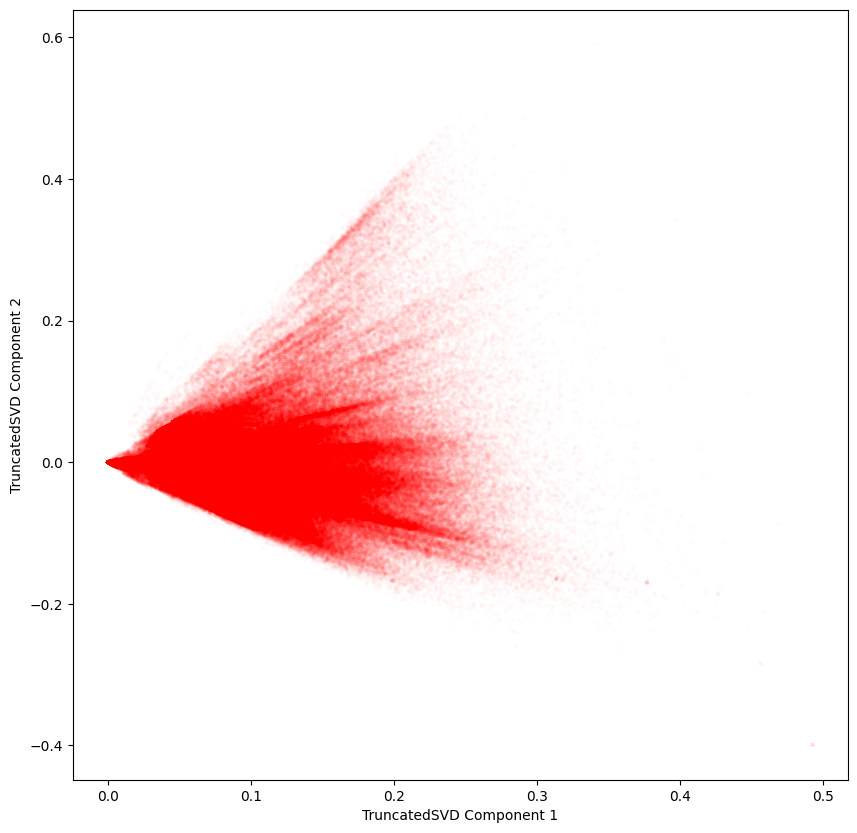

In [11]:
# Scatter plot 2차원으로 TruncatedSVD 변환 된 데이터 표현. 품종은 색깔로 구분
plt.figure(figsize=(10,10))

plt.scatter(x=pltdata[:,0], y= pltdata[:,1], s = 5, alpha = 0.01, c=colors)
plt.xlabel('TruncatedSVD Component 1')
plt.ylabel('TruncatedSVD Component 2')
plt.show()

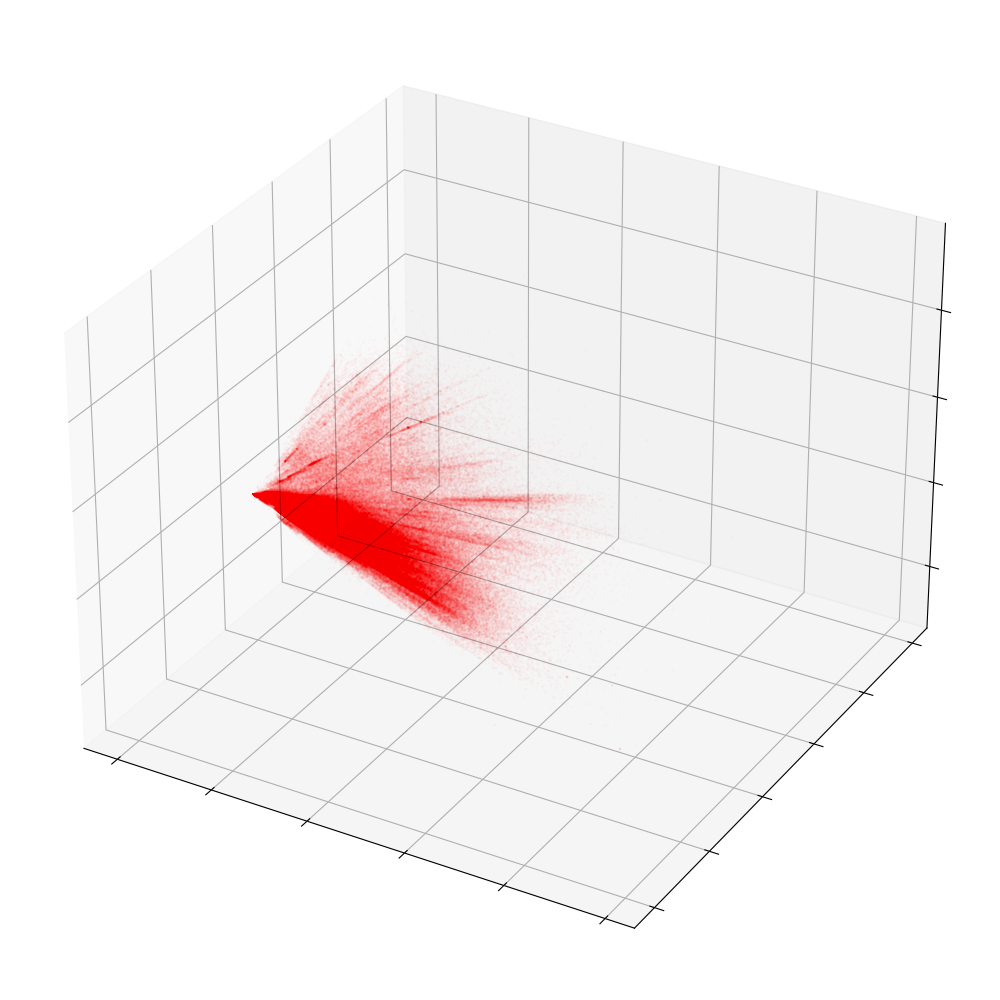

In [12]:
import matplotlib.pyplot as plt
import numpy as np

plt.style.use('_mpl-gallery')
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(pltdata[:,0], pltdata[:,1], pltdata[:,2], alpha = 0.01, s=1, c=colors)

ax.set(xticklabels=[],
       yticklabels=[],
       zticklabels=[])

plt.show()